In [1]:
import treemun_sim as tm

# Load forest from CSV file
bosque_c, resumen_c, biomasa_final_c, biomasa_estimada_c, carbon_estimada = tm.simular_bosque(
    archivo_rodales='.../treemun-sim-v1.3.0/examples/forest_stands.csv',  # Load from file
    policies_pino=[(9, 18), (10, 20), (11, 22)],
    policies_eucalyptus=[(9,), (10,), (11,)],
    horizonte=10,
    semilla=123,
    Carbon=True,
    return_carbon_opti=True
)

Cargando 105 rodales desde /home/postgrado/fulloa/treemun-sim-v1.3.0/examples/forest_stands.csv...

✓ Se cargaron 105 rodales válidos:
  - 30 rodales de Pinus
  - 75 rodales de Eucalyptus


In [2]:
model_npv = tm.forest_management_optimization_model(
    bosque_c, biomasa_final_c, biomasa_estimada_c,
    horizon=10,
    objective="npv",
    even_flow_tolerance=0.10
)

model_carbon = tm.forest_management_optimization_model(
    bosque_c, biomasa_final_c, biomasa_estimada_c,
    carbon_i_j_t=carbon_estimada,
    horizon=10,
    objective="carbon",
    even_flow_tolerance=0.10
)

model_weighted = tm.forest_management_optimization_model(
    bosque_c, biomasa_final_c, biomasa_estimada_c,
    carbon_i_j_t=carbon_estimada,
    horizon=10,
    objective="weighted",
    npv_weight=0.5,
    carbon_weight=0.5,
    even_flow_tolerance=0.10
)

In [3]:
results_npv = tm.solve_model(
    model_npv,
    solver_name="cplex",
    gap=0.01,
    tee=True
)

--- Solving with CPLEX | Gap: 1.0% ---

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'log_cplex.txt' open.
CPLEX> New value for mixed integer optimality gap tolerance: 0.01
CPLEX> Problem '/tmp/tmpde8ekpuw.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : /tmp/tmpde8ekpuw.pyomo.lp
Objective sense      : Maximize
Variables            :     264  [Nneg: 10,  Binary: 254]
Objective nonzeros   :     254
Linear constraints   :     125  [Less: 9,  Greater: 1,  Equal: 115]
  Nonzeros           :     793
  RHS nonzeros       :     106

Variables            : Min LB: 0.000000         Max UB: 1.000000       
Objective n

In [4]:
results_carbon = tm.solve_model(
    model_carbon,
    solver_name="cplex",
    gap=0.01,
    tee=True
)

--- Solving with CPLEX | Gap: 1.0% ---

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'log_cplex.txt' open.
CPLEX> New value for mixed integer optimality gap tolerance: 0.01
CPLEX> Problem '/tmp/tmpdn76zn2i.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : /tmp/tmpdn76zn2i.pyomo.lp
Objective sense      : Maximize
Variables            :     264  [Nneg: 10,  Binary: 254]
Objective nonzeros   :     254
Linear constraints   :     125  [Less: 9,  Greater: 1,  Equal: 115]
  Nonzeros           :     793
  RHS nonzeros       :     106

Variables            : Min LB: 0.000000         Max UB: 1.000000       
Objective n

In [5]:
results_biobjective = tm.solve_model(
    model_weighted,
    solver_name="cplex",
    gap=0.01,
    tee=True
)

--- Solving with CPLEX | Gap: 1.0% ---

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'log_cplex.txt' open.
CPLEX> New value for mixed integer optimality gap tolerance: 0.01
CPLEX> Problem '/tmp/tmp5ixymx4v.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : /tmp/tmp5ixymx4v.pyomo.lp
Objective sense      : Maximize
Variables            :     264  [Nneg: 10,  Binary: 254]
Objective nonzeros   :     254
Linear constraints   :     125  [Less: 9,  Greater: 1,  Equal: 115]
  Nonzeros           :     793
  RHS nonzeros       :     106

Variables            : Min LB: 0.000000         Max UB: 1.000000       
Objective n

--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
Results saved to: outputs/weighted_pareto_npv_carbon


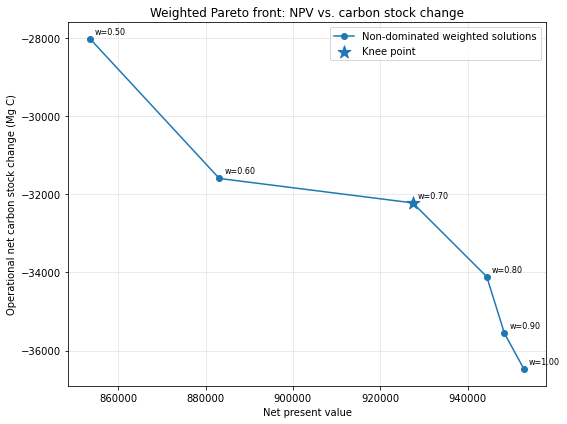

In [24]:
weights = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

pareto_df, fig, ax = tm.build_weighted_pareto_front(
    bosque=bosque_c,
    resumen=resumen_c,              # catálogo rodal-política de la simulación
    a_i_j_T=biomasa_final_c,
    a_i_j_t=biomasa_estimada_c,
    carbon_i_j_t=carbon_estimada,
    horizon=10,
    weights=weights,
    even_flow_tolerance=0.10,
    solver_name="cplex",
    gap=0.01,
    tee=False,
    make_plot=True,
    annotate_points=True,
    identify_knee=True,
    save_results=True,
    results_dir="outputs",
    run_name="weighted_pareto_npv_carbon",
)

In [7]:
pareto_df

,model_id,model_label,weight_npv,weight_carbon,objective_value,npv_value,carbon_seq_value,even_flow_tolerance,solver_status,termination_condition,solved,is_nondominated,is_knee
0,0,weighted_wNPV_0.0000_wC_1.0000,0.0,1.0,-0.330568,848463.842970,-27853.661340,0.1,ok,optimal,True,True,False
1,1,weighted_wNPV_0.1000_wC_0.9000,0.1,0.9,-0.262056,848463.842970,-27853.661340,0.1,ok,optimal,True,True,False
2,2,weighted_wNPV_0.2000_wC_0.8000,0.2,0.8,-0.194058,848986.613983,-27912.506200,0.1,ok,optimal,True,True,False
3,3,weighted_wNPV_0.3000_wC_0.7000,0.3,0.7,-0.125769,849739.409649,-27961.712204,0.1,ok,optimal,True,True,False
4,4,weighted_wNPV_0.4000_wC_0.6000,0.4,0.6,-0.056563,848652.301847,-27864.234877,0.1,ok,optimal,True,True,False
5,5,weighted_wNPV_0.5000_wC_0.5000,0.5,0.5,0.012071,853586.882504,-28020.901029,0.1,ok,optimal,True,True,False
6,6,weighted_wNPV_0.6000_wC_0.4000,0.6,0.4,0.071446,883153.105505,-31594.201472,0.1,ok,optimal,True,True,False
7,7,weighted_wNPV_0.7000_wC_0.3000,0.7,0.3,0.156569,927422.526525,-32219.808056,0.1,ok,optimal,True,True,True
8,8,weighted_wNPV_0.8000_wC_0.2000,0.8,0.2,0.234739,944362.140133,-34110.293604,0.1,ok,optimal,True,True,False
9,9,weighted_wNPV_0.9000_wC_0.1000,0.9,0.1,0.314486,948396.383114,-35555.471684,0.1,ok,optimal,True,True,False


--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished.

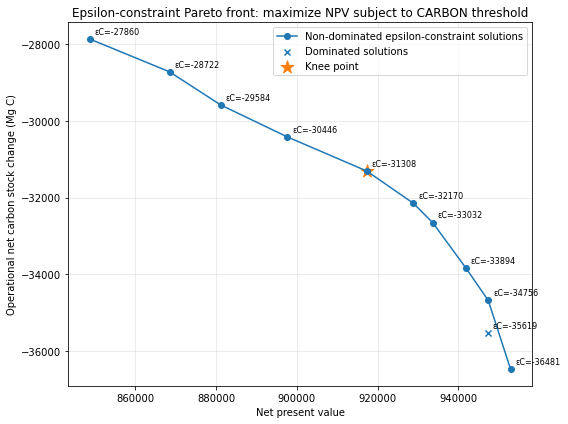

In [8]:
epsilon_df_npv, fig_npv, ax_npv = tm.build_epsilon_constraint_front(
    bosque=bosque_c,
    resumen=resumen_c,
    a_i_j_T=biomasa_final_c,
    a_i_j_t=biomasa_estimada_c,
    carbon_i_j_t=carbon_estimada,
    horizon=10,
    primary_objective="npv",
    epsilon_on="carbon",
    epsilon_mode="absolute",
    n_epsilons=11,
    even_flow_tolerance=0.10,
    min_ending_biomass=0,
    solver_name="cplex",
    gap=0.01,
    tee=False,
    make_plot=True,
    save_results=True,
    results_dir="outputs",
    run_name="epsilon_npv_with_carbon_thresholds",
)

In [9]:
epsilon_df_npv

,model_id,model_label,primary_objective,epsilon_on,epsilon_mode,epsilon_value,epsilon_relative,objective_value,npv_value,carbon_seq_value,even_flow_tolerance,solver_status,termination_condition,solved,is_nondominated,is_knee
0,0,epsilon_max_npv_carbon_000,npv,carbon,absolute,-36480.694690,None,952902.811660,952902.811660,-36480.694690,0.1,ok,optimal,True,True,False
1,1,epsilon_max_npv_carbon_001,npv,carbon,absolute,-35618.591364,None,947262.826504,947262.826504,-35536.314668,0.1,ok,optimal,True,False,False
2,2,epsilon_max_npv_carbon_002,npv,carbon,absolute,-34756.488038,None,947375.680964,947375.680964,-34684.474643,0.1,ok,optimal,True,True,False
3,3,epsilon_max_npv_carbon_003,npv,carbon,absolute,-33894.384712,None,941853.369670,941853.369670,-33840.075231,0.1,ok,optimal,True,True,False
4,4,epsilon_max_npv_carbon_004,npv,carbon,absolute,-33032.281386,None,933612.163374,933612.163374,-32653.356964,0.1,ok,optimal,True,True,False
5,5,epsilon_max_npv_carbon_005,npv,carbon,absolute,-32170.178060,None,928824.758397,928824.758397,-32148.363974,0.1,ok,optimal,True,True,False
6,6,epsilon_max_npv_carbon_006,npv,carbon,absolute,-31308.074735,None,917293.602965,917293.602965,-31307.638312,0.1,ok,optimal,True,True,True
7,7,epsilon_max_npv_carbon_007,npv,carbon,absolute,-30445.971409,None,897633.668594,897633.668594,-30417.598337,0.1,ok,optimal,True,True,False
8,8,epsilon_max_npv_carbon_008,npv,carbon,absolute,-29583.868083,None,881131.698239,881131.698239,-29583.545607,0.1,ok,optimal,True,True,False
9,9,epsilon_max_npv_carbon_009,npv,carbon,absolute,-28721.764757,None,868447.291783,868447.291783,-28717.672172,0.1,ok,optimal,True,True,False


--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
--- Solving with CPLEX | Gap: 1.0% ---
--- Solving finished. Log saved to 'log_cplex.txt' ---
Results saved to: outputs/epsilon_carbon_with_npv_thresholds


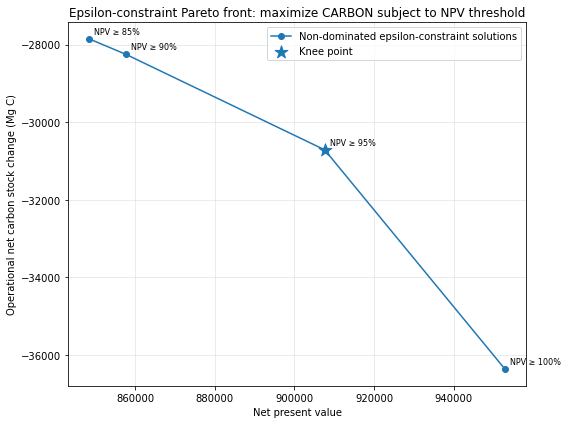

In [14]:
epsilon_df_carbon, fig_carbon, ax_carbon = tm.build_epsilon_constraint_front(
    bosque=bosque_c,
    resumen=resumen_c,
    a_i_j_T=biomasa_final_c,
    a_i_j_t=biomasa_estimada_c,
    carbon_i_j_t=carbon_estimada,
    horizon=10,
    primary_objective="carbon",
    epsilon_on="npv",
    epsilon_mode="relative",
    epsilons=[0.85, 0.90, 0.95, 1.00],
    even_flow_tolerance=0.10,
    solver_name="cplex",
    gap=0.01,
    tee=False,
    make_plot=True,
    save_results=True,
    results_dir="outputs",
    run_name="epsilon_carbon_with_npv_thresholds",
)

In [15]:
epsilon_df_carbon

,model_id,model_label,primary_objective,epsilon_on,epsilon_mode,epsilon_value,epsilon_relative,objective_value,npv_value,carbon_seq_value,even_flow_tolerance,solver_status,termination_condition,solved,is_nondominated,is_knee
0,0,epsilon_max_carbon_NPV_85.0pct,carbon,npv,relative,809967.389911,0.85,-27853.661340,848463.842970,-27853.661340,0.1,ok,optimal,True,True,False
1,1,epsilon_max_carbon_NPV_90.0pct,carbon,npv,relative,857612.530494,0.90,-28252.210822,857698.549591,-28252.210822,0.1,ok,optimal,True,True,False
2,2,epsilon_max_carbon_NPV_95.0pct,carbon,npv,relative,905257.671077,0.95,-30711.976328,907584.803513,-30711.976328,0.1,ok,optimal,True,True,True
3,3,epsilon_max_carbon_NPV_100.0pct,carbon,npv,relative,952902.811660,1.00,-36368.439935,952914.160221,-36368.439935,0.1,ok,optimal,True,True,False


In [22]:
import treemun_sim as tm

# ---------------------------------------------------------------------
# 1. Simulate forest from CSV file
# ---------------------------------------------------------------------

# Load forest from CSV file
bosque_c, resumen_c, biomasa_final_c, biomasa_estimada_c, carbon_estimada = tm.simular_bosque(
    archivo_rodales='.../treemun-sim-v1.3.0/examples/forest_stands.csv',  # Load from file
    policies_pino=[(9, 18), (10, 20), (11, 22)],
    policies_eucalyptus=[(9,), (10,), (11,)],
    horizonte=10,
    semilla=123,
    Carbon=True,
    return_carbon_opti=True
)

# ---------------------------------------------------------------------
# 2. Build optimization model
# ---------------------------------------------------------------------
model_npv = tm.forest_management_optimization_model(
    bosque=bosque_c,
    a_i_j_T=biomasa_final_c,
    a_i_j_t=biomasa_estimada_c,
    horizon=10,
    objective="npv",
    even_flow_tolerance=0.10,
)

# ---------------------------------------------------------------------
# 3. Solve optimization model
# ---------------------------------------------------------------------
results_npv = tm.solve_model(
    model_npv,
    solver_name="cplex",
    gap=0.01,
    tee=True,
)

# ---------------------------------------------------------------------
# 4. Extract optimization results
# ---------------------------------------------------------------------
solution_npv = tm.extract_results(
    model_npv,
    results_npv,
)

# ---------------------------------------------------------------------
# 5. Export selected optimal policies to spatial file
# ---------------------------------------------------------------------


gdf_npv_bio = tm.export_optimal_policy_to_shapefile(
    forest=bosque_c,
    summary=resumen_c,
    shapefile_input=".../treemun-sim-v1.3.0/examples/shapefile/treemun_landscape.shp",
    shapefile_output=".../treemun-sim-v1.3.0/examples/shapefile/solutions/solution_npv_biomass.gpkg",
    solution=solution_npv,
    biom_simu=True,
)

gdf_npv_bio.head()

Cargando 105 rodales desde /home/postgrado/fulloa/treemun-sim-v1.3.0/examples/forest_stands.csv...

✓ Se cargaron 105 rodales válidos:
  - 30 rodales de Pinus
  - 75 rodales de Eucalyptus
--- Solving with CPLEX | Gap: 1.0% ---

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'log_cplex.txt' open.
CPLEX> New value for mixed integer optimality gap tolerance: 0.01
CPLEX> Problem '/tmp/tmpu7g9qsmf.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : /tmp/tmpu7g9qsmf.pyomo.lp
Objective sense      : Maximize
Variables            :     264  [Nneg: 10,  Binary: 254]
Objective nonzeros   :     254
Linear constraints   :    

,id_rodal,especie,edad_ini,area_ha,geometry,opt_policy,bio_P2_t1,bio_P2_t2,bio_P2_t3,bio_P2_t4,...,bio_P3_t1,bio_P3_t2,bio_P3_t3,bio_P3_t4,bio_P3_t5,bio_P3_t6,bio_P3_t7,bio_P3_t8,bio_P3_t9,bio_P3_t10
0,stand1,Eucapyltus,1,1.515,"POLYGON ((637709.707 5838544.24, 637709.472 58...",policy_eucalyptus 2,11.79,33.63,62.12,96.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,stand2,Eucapyltus,1,0.090,"POLYGON ((637398.481 5838552.178, 637377.3 583...",policy_eucalyptus 2,0.48,1.45,2.77,4.39,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,stand3,Eucapyltus,5,2.366,"POLYGON ((635673.04 5836728.572, 635676.371 58...",policy_eucalyptus 3,NaN,NaN,NaN,NaN,...,210.13,276.87,349.60,427.87,511.34,599.71,692.73,18.41,52.53,97.01
3,stand4,Eucapyltus,1,0.289,"POLYGON ((638498.118 5837175.518, 638498.07 58...",policy_eucalyptus 2,1.53,4.65,8.89,14.09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,stand5,Eucapyltus,7,2.646,"POLYGON ((637517.001 5837355.27, 637523.555 58...",policy_eucalyptus 3,NaN,NaN,NaN,NaN,...,281.08,348.87,422.11,500.56,584.03,12.06,37.03,71.36,113.66,163.08


In [23]:
gdf_npv_bio_carbon = tm.export_optimal_policy_to_shapefile(
    forest=bosque_c,
    summary=resumen_c,
    shapefile_input=".../treemun-sim-v1.3.0/examples/shapefile/treemun_landscape.shp",
    shapefile_output=".../treemun-sim-v1.3.0/examples/shapefile/solutions/solution_npv_biomass_carbon.gpkg",
    solution=solution_npv,
    biom_simu=True,
    carbseqSim=True,
)

gdf_npv_bio_carbon.head()


✓ Solución óptima exportada: /home/postgrado/fulloa/treemun-sim-v1.3.0/examples/shapefile/solutions/solution_npv_biomass_carbon.gpkg
  - Rodales en archivo espacial: 105
  - Rodales con opt_policy: 105
  - biom_simu: True
  - carbseqSim: True


,id_rodal,especie,edad_ini,area_ha,geometry,opt_policy,bio_P2_t1,CSeqP2_t1,bio_P2_t2,CSeqP2_t2,...,bio_P3_t6,CSeqP3_t6,bio_P3_t7,CSeqP3_t7,bio_P3_t8,CSeqP3_t8,bio_P3_t9,CSeqP3_t9,bio_P3_t10,CSeqP3_t10
0,stand1,Eucapyltus,1,1.515,"POLYGON ((637709.707 5838544.24, 637709.472 58...",policy_eucalyptus 2,11.79,0.0,33.63,6.32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,stand2,Eucapyltus,1,0.090,"POLYGON ((637398.481 5838552.178, 637377.3 583...",policy_eucalyptus 2,0.48,0.0,1.45,0.28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,stand3,Eucapyltus,5,2.366,"POLYGON ((635673.04 5836728.572, 635676.371 58...",policy_eucalyptus 3,NaN,NaN,NaN,NaN,...,599.71,25.55,692.73,-173.42,18.41,5.32,52.53,9.87,97.01,12.86
3,stand4,Eucapyltus,1,0.289,"POLYGON ((638498.118 5837175.518, 638498.07 58...",policy_eucalyptus 2,1.53,0.0,4.65,0.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,stand5,Eucapyltus,7,2.646,"POLYGON ((637517.001 5837355.27, 637523.555 58...",policy_eucalyptus 3,NaN,NaN,NaN,NaN,...,12.06,3.49,37.03,7.22,71.36,9.93,113.66,12.23,163.08,14.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,stand101,Pinus,18,3.408,"POLYGON ((637644.37 5837380.89, 637631.982 583...",policy_pino 1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,stand102,Pinus,12,17.882,"POLYGON ((637538.993 5837945.54, 637541.321 58...",policy_pino 2,940.18,0.0,1260.30,57.93,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102,stand103,Pinus,11,7.268,"POLYGON ((638215.72 5838381.543, 638218.648 58...",policy_pino 1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,stand104,Eucapyltus,1,0.279,"POLYGON ((637791.651 5835924.384, 637783.06 58...",policy_eucalyptus 2,2.17,0.0,6.19,1.16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
